# Label transfer test
Here we're testing how well label transfer from RNA to ATAC worked by compare gene expression (RNA) and gene activity (ATAC) for cell-type marker genes

In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

In [29]:
library(SingleCellExperiment)
library(batchelor)
library(scran)
library(scater)

In [3]:
# I/O
io$outdir =  file.path(io$output.directory,"QualityControl")

addArchRThreads(16)
options(repr.plot.width=15, repr.plot.height=10)

Setting default number of Parallel threads to 16.



In [4]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR"

In [48]:
genes = as.data.table(ArchRProject@geneAnnotation$genes) %>% 
    .[,width:=end-start]

In [169]:
# short genes mess up gene scores so remove from analysis
short_genes = genes[width<1500, symbol]

In [53]:
length(short_genes)

[1] 4450

In [280]:
gene_counts = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix",
  binarize = FALSE,
  threads = getArchRThreads())

In [281]:
counts = gene_counts@assays@data$GeneScoreMatrix
logcounts = log2(counts+1)

In [282]:
sce = SingleCellExperiment(list(counts = counts, logcounts=logcounts),
    colData=colData(gene_counts))

In [283]:
rownames(sce) = rowData(gene_counts)$name

In [284]:
# filter out short genes
genes_keep = genes[!symbol%in% short_genes, symbol]
sce = sce[genes_keep, ] 

In [285]:
sce

class: SingleCellExperiment 
dim: 14380 34082 
metadata(0):
assays(2): counts logcounts
rownames(14380): WDR31 PRPF4 ... ENSOCUG00000007220 ENSOCUG00000029751
rowData names(0):
colnames(34082): rabbit_BGRGP1#CAAGGCCGTATACGCT-1
  rabbit_BGRGP1#ATCCTCGTCCGAATTG-1 ... rabbit_BGRGP4#CCTTGCATCATCATGG-1
  rabbit_BGRGP4#TAAGTGCGTGTTTCTT-1
colData names(25): DoubletEnrichment DoubletScore ... cell celltype_v1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [172]:
#######################
## Feature selection ##
#######################

decomp <- modelGeneVar(sce, block=colData(sce)[['Sample']])

decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce[hvgs,]

In [129]:
head(hvgs, 100)

[1] "ENSOCUG00000032981" "ENSOCUG00000039498" "CUBN"              
  [4] "ENSOCUG00000027365" "TRPC5"              "APOA4"             
  [7] "CCL2"               "GPR119"             "ENSOCUG00000030923"
 [10] "AFP"                "ENSOCUG00000030749" "ENSOCUG00000036033"
 [13] "CORT"               "ENSOCUG00000036930" "ENSOCUG00000034029"
 [16] "CALN1"              "APOA1"              "KCND3"             
 [19] "ENSOCUG00000038832" "ENSOCUG00000037813" "ENSOCUG00000025716"
 [22] "ENSOCUG00000035241" "ENSOCUG00000030491" "OR52E1"            
 [25] "SPEM1"              "ENSOCUG00000039221" "ASIC2"             
 [28] "LPIN1"              "ENSOCUG00000032420" "ENSOCUG00000008258"
 [31] "ENSOCUG00000035301" "ENSOCUG00000035827" "ENSOCUG00000035213"
 [34] "ENSOCUG00000028024" "IL1RAPL2"           "DPP6"              
 [37] "ENSOCUG00000012976" "ENSOCUG00000035577" "ENSOCUG00000015148"
 [40] "ENSOCUG00000036612" "LTB4R"              "MPV17"             
 [43] "ENSOCUG00000036574" "OTUD6A"             "ENSOCUG00000037701"
 [46] "UBQLNL"             "ENSOCUG00000029948" "ENSOCUG00000031558"
 [49] "ENSOCUG00000028118" "ENSOCUG00000030779" "ENSOCUG00000025152"
 [52] "MAGEB10"            "ENSOCUG00000033812" "ENSOCUG00000022866"
 [55] "ENSOCUG00000033487" "ENSOCUG00000036601" "SPEM2"             
 [58] "ENSOCUG00000013059" "B3GNT6"             "ENSOCUG00000024425"
 [61] "ENSOCUG00000031372" "ENSOCUG00000033442" "ENSOCUG00000031886"
 [64] "ENSOCUG00000037566" "ENSOCUG00000033039" "ENSOCUG00000030703"
 [67] "ENSOCUG00000033765" "ENSOCUG00000036259" "ENSOCUG00000036152"
 [70] "ENSOCUG00000035810" "ENSOCUG00000037231" "ENSOCUG00000035209"
 [73] "ENSOCUG00000037623" "ENSOCUG00000032926" "HOXA4"             
 [76] "ENSOCUG00000036603" "ENSOCUG00000033727" "ENSOCUG00000014400"
 [79] "ENSOCUG00000001988" "ENSOCUG00000035360" "ENSOCUG00000033160"
 [82] "LTB4R2"             "ITSN2"              "ASTN1"             
 [85] "ENSOCUG00000029379" "AIF1"               "C2orf74"           
 [88] "ENSOCUG00000033772" "ENSOCUG00000032309" "ENSOCUG00000027630"
 [91] "ENSOCUG00000033179" "ENSOCUG00000022819" "PAQR7"             
 [94] "ENSOCUG00000038426" "ENSOCUG00000037851" "ENSOCUG00000030159"
 [97] "ENSOCUG00000033805" "ENSOCUG00000032267" "C16orf86"          
[100] "ENSOCUG00000036012"

In [173]:
sce_filt <- runPCA(sce_filt, ncomponents = 25, ntop=4000)  

In [174]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 35, min_dist = 0.3)

In [175]:
# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>%
    merge(., as.data.table(colData(sce)), by='cell')

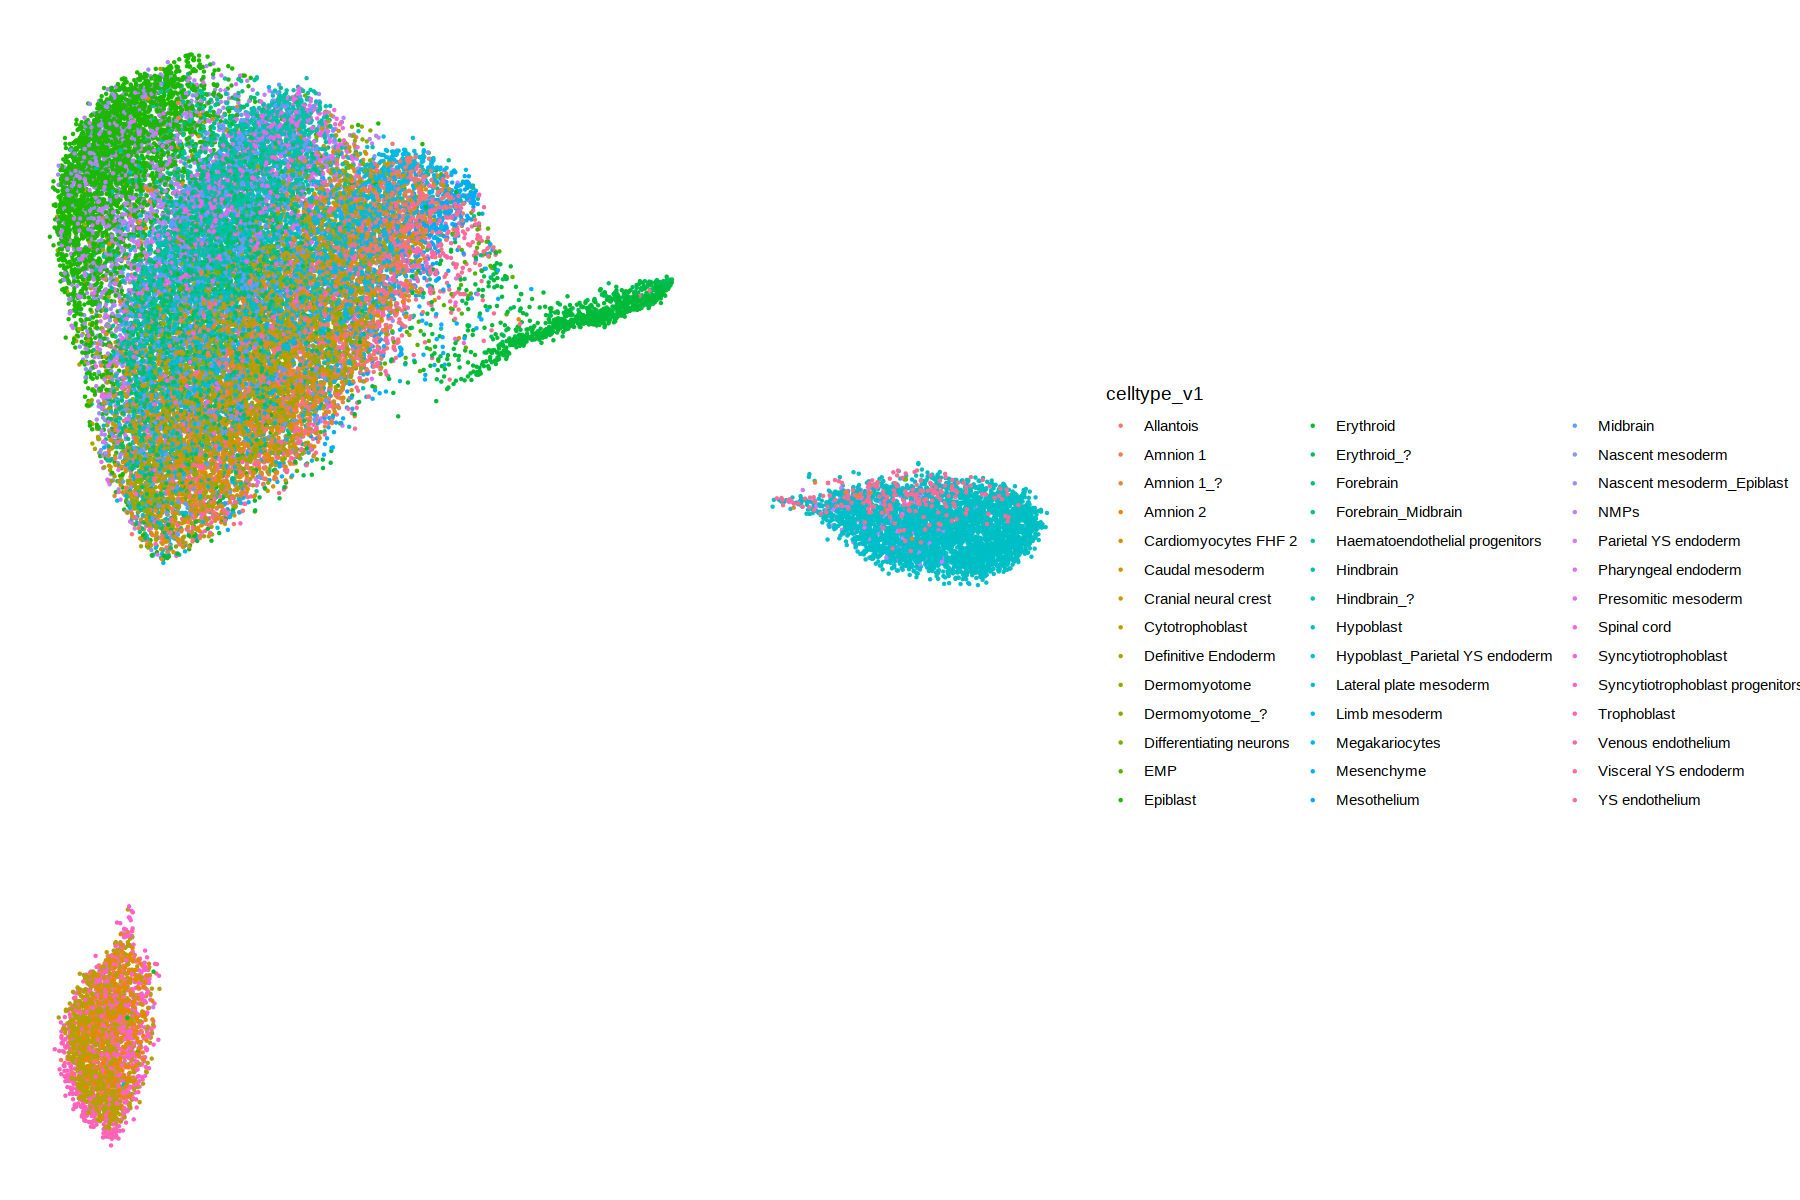

In [176]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype_v1)) + 
    geom_point(size=0.2) + 
    theme_void()

In [288]:
# only on embryo proper:
meta = as.data.table(colData(sce))
ct_excl = c('Hypoblast_Parietal YS endoderm',
           'Trophoblast', 
           'Hypoblast',
           'Parietal YS endoderm',
           'Cytotrophoblast',
            'Syncytiotrophoblast',
           'Syncytiotrophoblast progenitors',
           'Amnion 1',
           'Amnion 1_?',
           'Visceral YS endoderm',
            'Amnion 2')
meta_filt = meta[!celltype_v1 %in% ct_excl]

In [289]:
sce_filt = sce[,meta_filt$cell]

In [179]:
sce_filt

class: SingleCellExperiment 
dim: 15090 26581 
metadata(0):
assays(1): logcounts
rownames(15090): WDR31 PRPF4 ... ENSOCUG00000029751 GPR101
rowData names(0):
colnames(26581): rabbit_BGRGP1#ATCCTCGTCCGAATTG-1
  rabbit_BGRGP1#CTTGCCATCTGAGTAC-1 ... rabbit_BGRGP4#CCTTGCATCATCATGG-1
  rabbit_BGRGP4#TAAGTGCGTGTTTCTT-1
colData names(25): DoubletEnrichment DoubletScore ... cell celltype_v1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [180]:
#######################
## Feature selection ##
#######################

decomp <- modelGeneVar(sce_filt, block=colData(sce_filt)[['Sample']])

decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=2500) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce_filt[hvgs,]

In [182]:
head(hvgs, 100)

[1] "HOXA7"              "LBX2"               "HOXA2"             
  [4] "HOXD4"              "ENSOCUG00000035633" "HOXB2"             
  [7] "ENSOCUG00000034810" "C16orf86"           "HOXB3"             
 [10] "YDJC"               "ENSOCUG00000009996" "PGAM2"             
 [13] "ENSOCUG00000000854" "ENSOCUG00000033324" "HOXA9"             
 [16] "HYPK"               "ABHD14B"            "ENSOCUG00000004005"
 [19] "HOXA11"             "ENSOCUG00000014583" "ENSOCUG00000023956"
 [22] "HOXA10"             "ENSOCUG00000036001" "MZB1"              
 [25] "EGFL8"              "ENSOCUG00000005485" "TLCD2"             
 [28] "ENSOCUG00000030703" "ENSOCUG00000029764" "ENSOCUG00000017652"
 [31] "ENSOCUG00000037491" "PARD6A"             "POU3F3"            
 [34] "CYB561D2"           "ENSOCUG00000038759" "MRPS26"            
 [37] "ENSOCUG00000021347" "ENSOCUG00000031816" "CMTM5"             
 [40] "HOXA3"              "GPS2"               "ENSOCUG00000004743"
 [43] "SLC35B2"            "CCR10"              "FAM131A"           
 [46] "HOXB6"              "PPP1CA"             "CTRL"              
 [49] "HOXC11"             "TMEM151B"           "POU4F1"            
 [52] "ENSOCUG00000033604" "ENSOCUG00000014136" "NPM3"              
 [55] "PSMB10"             "S100A5"             "ENSOCUG00000031505"
 [58] "ATP6V1FNB"          "APOM"               "ENSOCUG00000039671"
 [61] "ENSOCUG00000038339" "ENSOCUG00000001058" "ENSOCUG00000030564"
 [64] "MDP1"               "ENSOCUG00000010066" "ENSOCUG00000031995"
 [67] "ORMDL3"             "ENSOCUG00000034540" "TLCD1"             
 [70] "SPSB2"              "ENSOCUG00000036152" "IL18BP"            
 [73] "ENSOCUG00000002563" "ENSOCUG00000024081" "ZFP36"             
 [76] "NPRL2"              "RBM3"               "ENSOCUG00000005262"
 [79] "ENSOCUG00000000689" "TMEM101"            "CIDEB"             
 [82] "AP5S1"              "ENSOCUG00000029379" "ENSOCUG00000038925"
 [85] "ENSOCUG00000025839" "TMEM107"            "SH2B3"             
 [88] "FBXL22"             "ENSOCUG00000037215" "HSD17B8"           
 [91] "TPI1"               "ENSOCUG00000036290" "DPH2"              
 [94] "AGPAT1"             "SNAPC5"             "ENSOCUG00000012476"
 [97] "ENSOCUG00000022954" "DLX1"               "TMEM115"           
[100] "PCGF1"

In [183]:
sce_filt <- runPCA(sce_filt, ncomponents = 15, ntop=2500)  

In [184]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 35, min_dist = 0.3)

In [185]:
# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>%
    merge(., as.data.table(colData(sce)), by='cell')

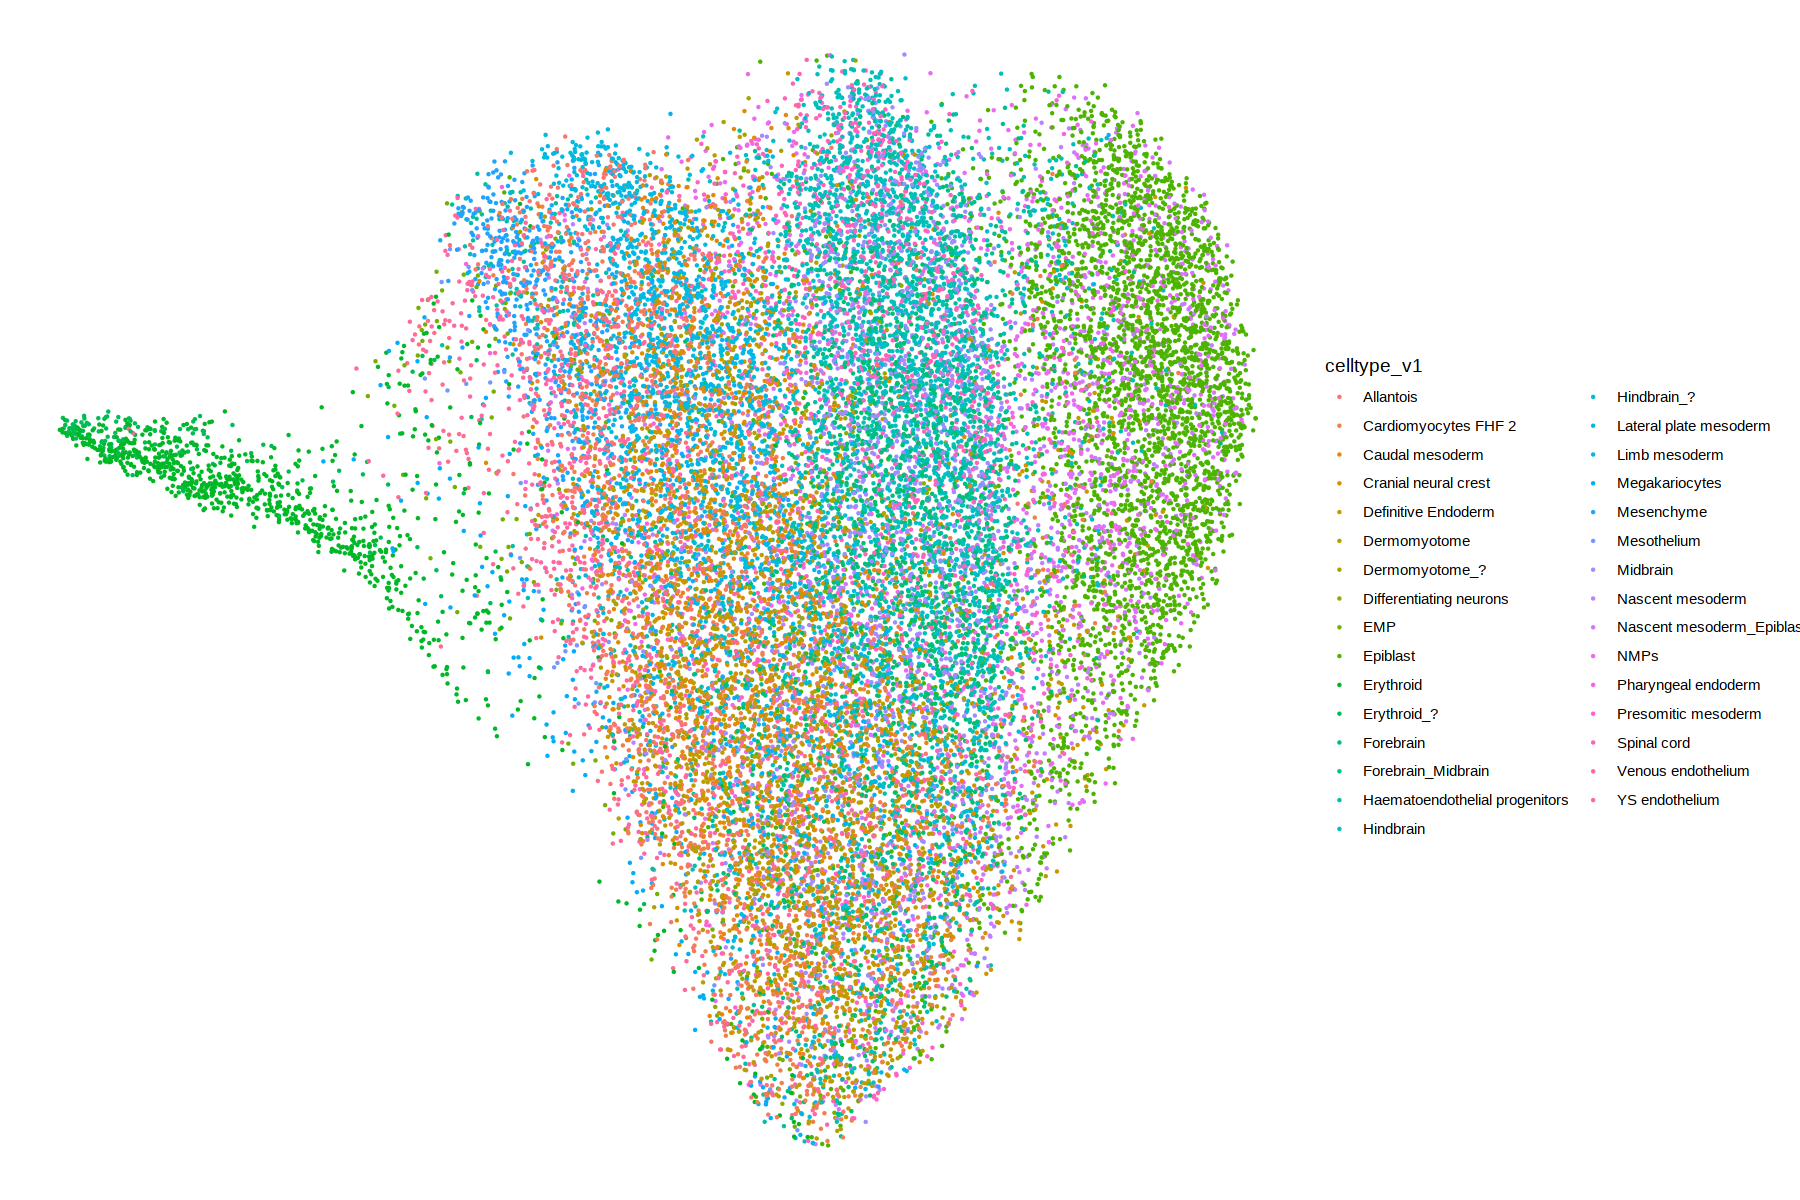

In [186]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype_v1)) + 
    geom_point(size=0.2) + 
    theme_void()

In [187]:
# Also remove all unannotated genes

In [286]:
ENSOCUG = genes[grep('^ENSOCUG', symbol), symbol]

In [287]:
# filter out short genes 
# short genes mess up gene scores so remove from analysis
short_genes = genes[width<2000, symbol]

genes_keep = genes[!symbol%in% short_genes][!symbol %in% ENSOCUG][, symbol]
sce = sce[genes_keep, ] 

In [190]:
sce_filt = sce[,meta_filt$cell]

In [191]:
sce_filt

class: SingleCellExperiment 
dim: 8900 26581 
metadata(0):
assays(1): logcounts
rownames(8900): WDR31 PRPF4 ... CD40LG ARHGEF6
rowData names(0):
colnames(26581): rabbit_BGRGP1#ATCCTCGTCCGAATTG-1
  rabbit_BGRGP1#CTTGCCATCTGAGTAC-1 ... rabbit_BGRGP4#CCTTGCATCATCATGG-1
  rabbit_BGRGP4#TAAGTGCGTGTTTCTT-1
colData names(25): DoubletEnrichment DoubletScore ... cell celltype_v1
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [192]:
#######################
## Feature selection ##
#######################

decomp <- modelGeneVar(sce_filt, block=colData(sce_filt)[['Sample']])

decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=5000) %>% rownames

# Subset SingleCellExperiment
sce_filt <- sce_filt[hvgs,]

In [193]:
head(hvgs, 100)

[1] "HOXB3"    "ABHD14B"  "HOXA11"   "HOXA10"   "CYB561D2" "HOXA3"   
  [7] "FAM131A"  "GPS2"     "SLC35B2"  "HOXB6"    "PPP1CA"   "NPM3"    
 [13] "PSMB10"   "TMEM151B" "HOXC11"   "TLCD1"    "NPRL2"    "ZFP36"   
 [19] "SNAPC5"   "DLX1"     "FBXL22"   "PCGF1"    "TPI1"     "AGPAT1"  
 [25] "TMEM115"  "IL18BP"   "TMEM101"  "CYB5D1"   "TMEM208"  "CIDEB"   
 [31] "DPH2"     "RELL2"    "SH2B3"    "CCDC24"   "NAXE"     "SCRN2"   
 [37] "DDAH2"    "INKA1"    "CCNO"     "STK16"    "KLHDC9"   "FAM110D" 
 [43] "AGER"     "LY6G6C"   "PROB1"    "TUFM"     "KNCN"     "SHISA4"  
 [49] "ITPKA"    "KLHDC8B"  "CBLN3"    "DOK1"     "HOXB8"    "PSME1"   
 [55] "LCAT"     "TLX2"     "MOB3C"    "SIGMAR1"  "BCS1L"    "ATP6V0B" 
 [61] "S100A4"   "MRPL11"   "YPEL3"    "FBXL15"   "OTX1"     "B3GALT4" 
 [67] "ZFAND2B"  "APH1A"    "RABIF"    "INHA"     "GPANK1"   "POLR1C"  
 [73] "CRYBA2"   "STOML2"   "MTX1"     "HYAL2"    "HIRIP3"   "TBX6"    
 [79] "SDF2L1"   "THTPA"    "RPS12"    "HOXD12"   "SLC25A11" "RITA1"   
 [85] "ANKRD37"  "ART5"     "SMIM4"    "SETD6"    "PIMREG"   "DALRD3"  
 [91] "MTFP1"    "LRRC73"   "CDK5"     "PLK3"     "GPR162"   "GAREM2"  
 [97] "GLMP"     "SIX6"     "TMED4"    "TOMM40L"

In [194]:
sce_filt <- runPCA(sce_filt, ncomponents = 15, ntop=5000)  

In [195]:
sce_filt <- runUMAP(sce_filt, dimred="PCA", n_neighbors = 35, min_dist = 0.3)

In [196]:
# Fetch UMAP coordinates
umap.dt <- reducedDim(sce_filt,"UMAP") %>% as.data.table %>% 
  .[,cell:=colnames(sce_filt)] %>%
  setnames(c("UMAP1","UMAP2","cell")) %>%
    merge(., as.data.table(colData(sce)), by='cell')

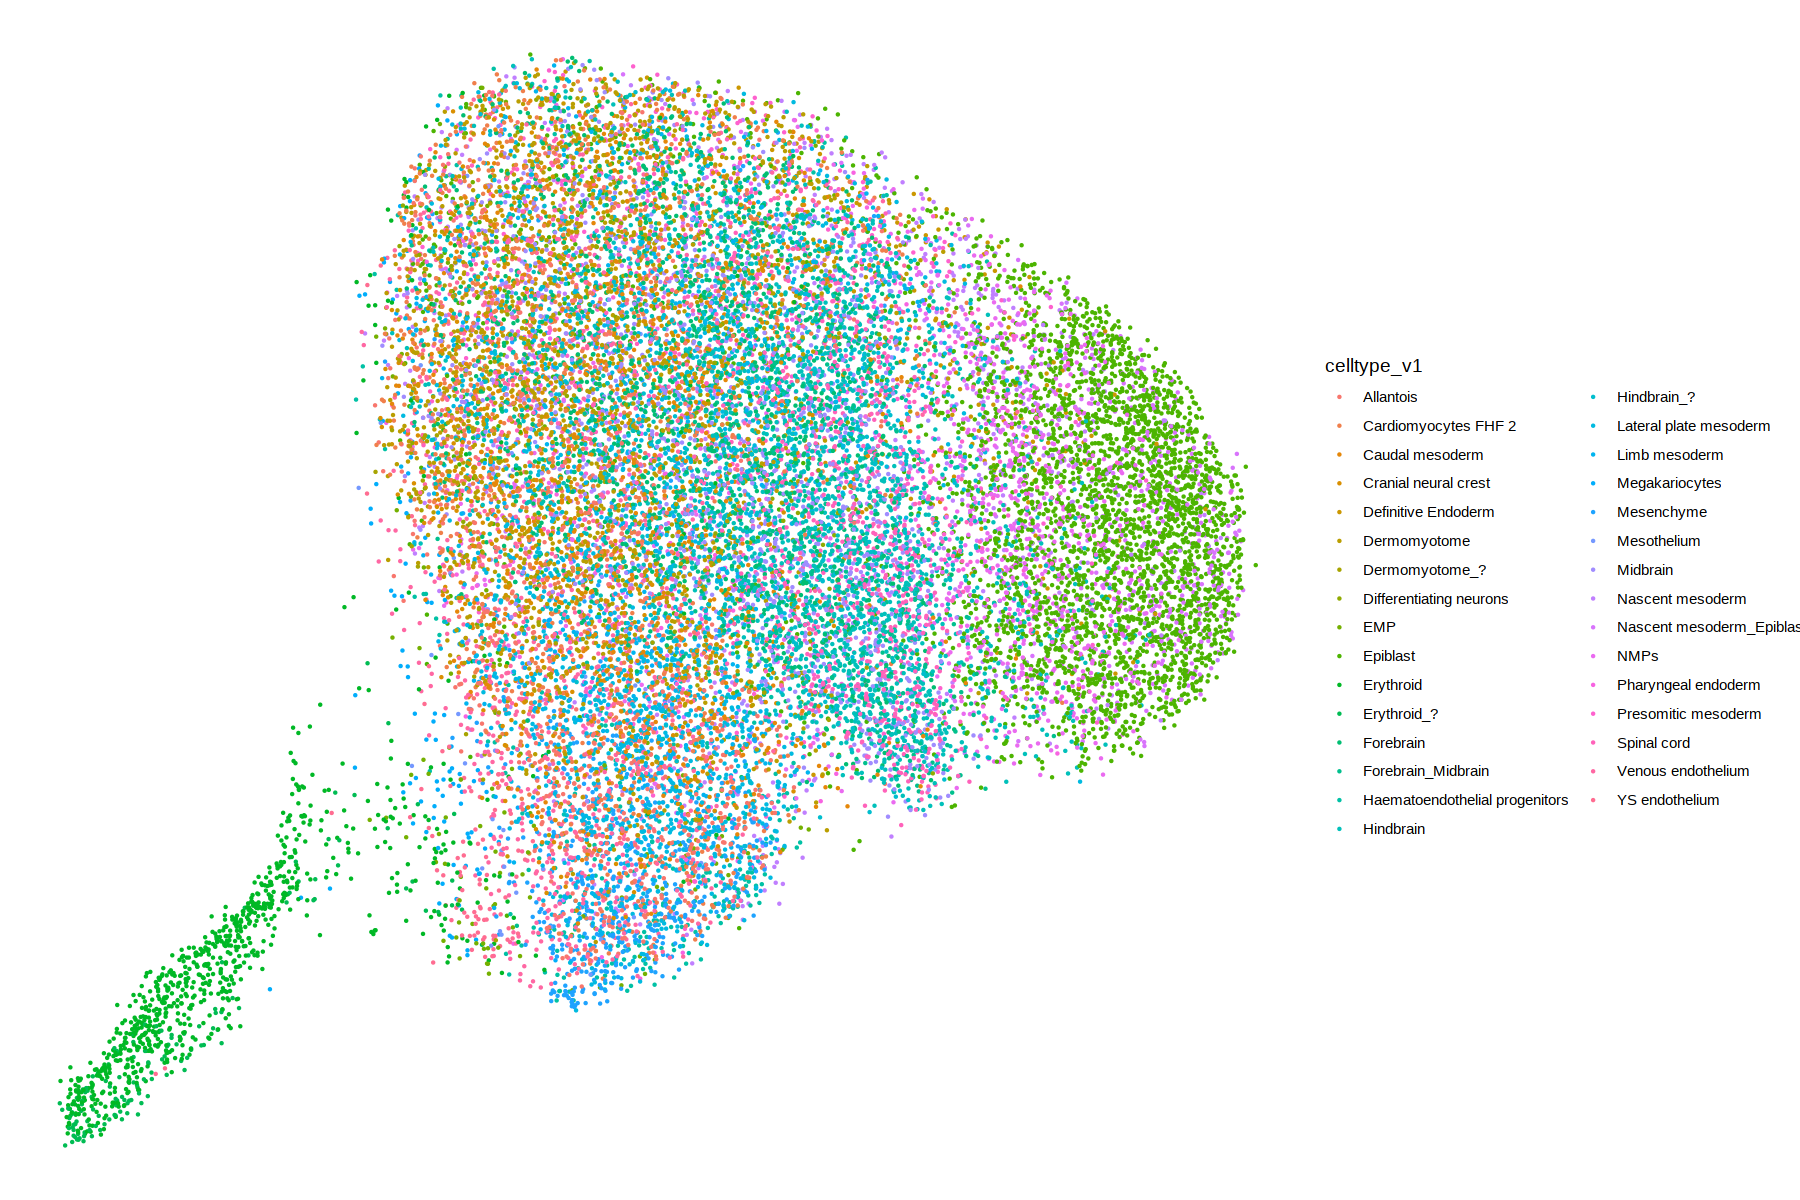

In [197]:
ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype_v1)) + 
    geom_point(size=0.2) + 
    theme_void()

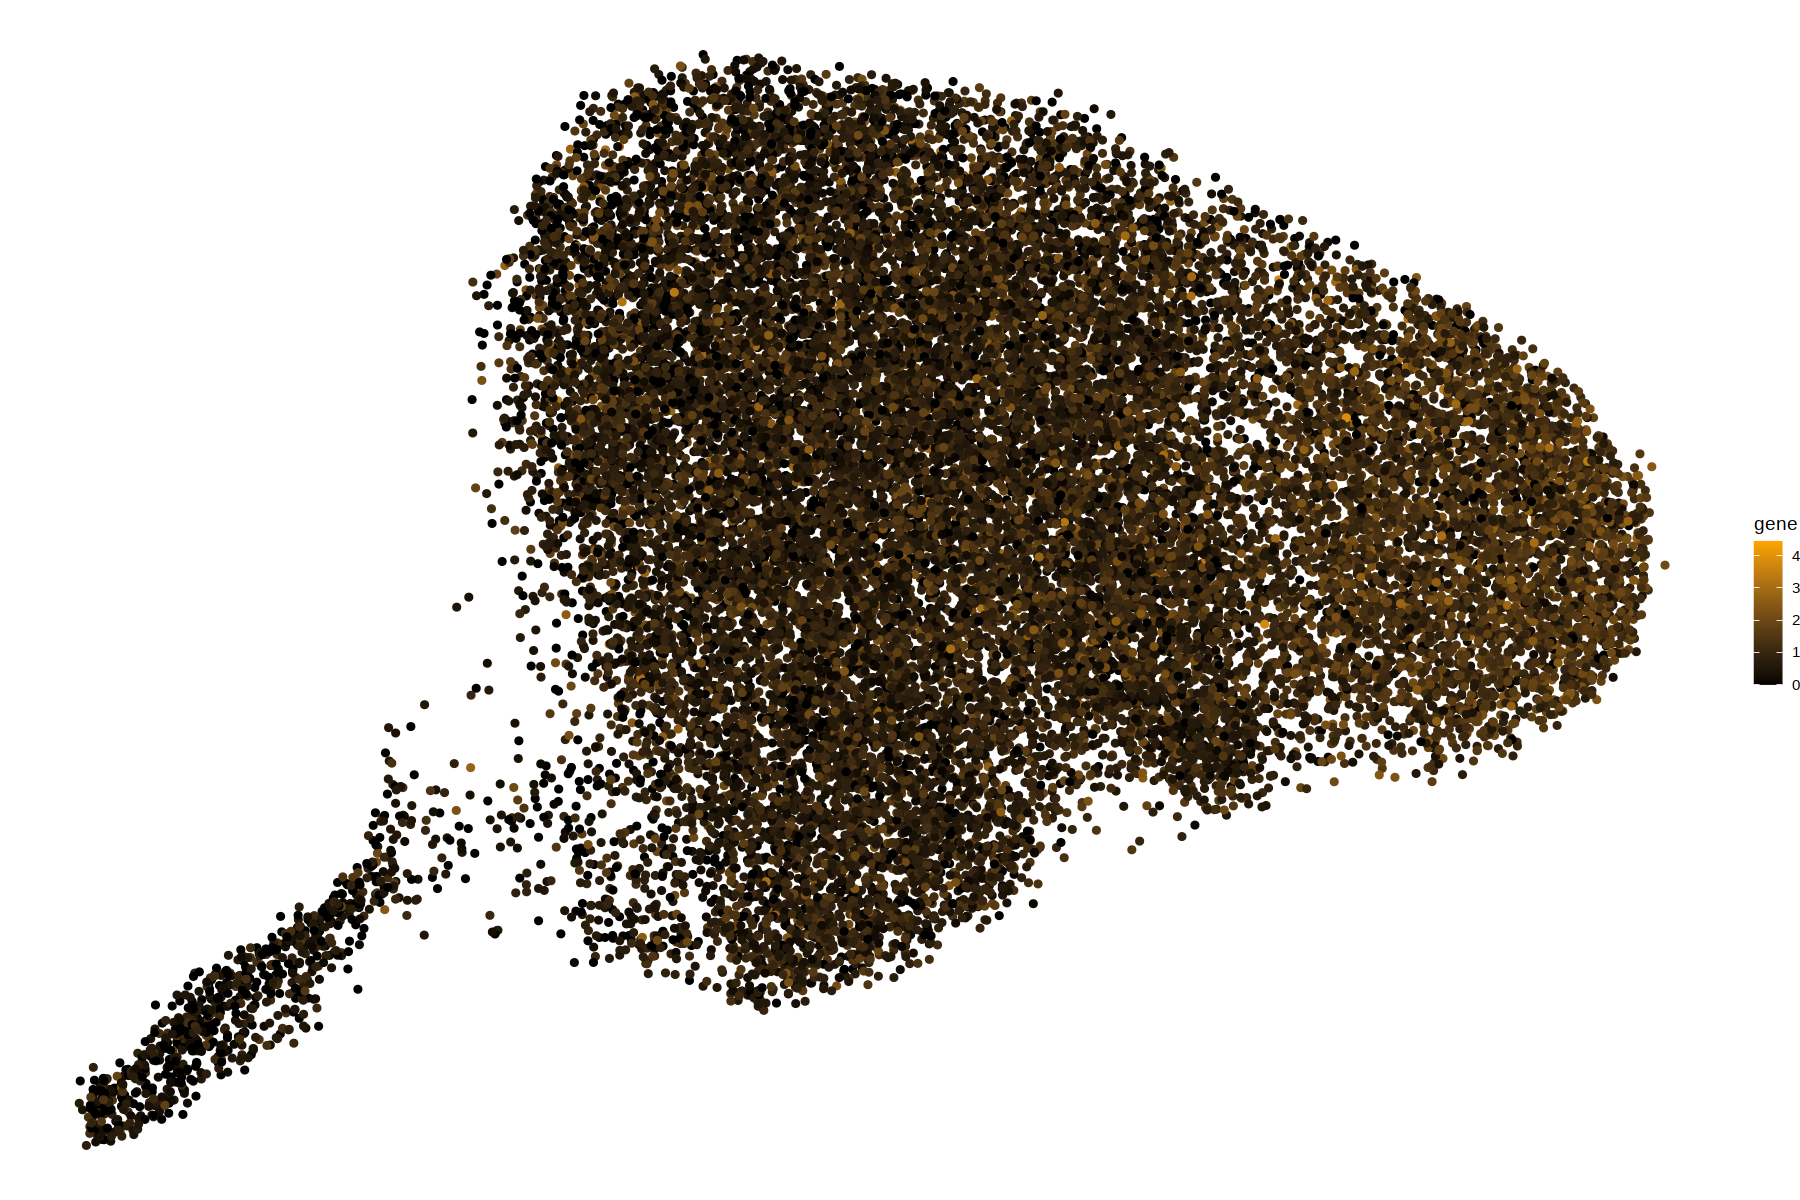

In [ ]:
gene = 'OTX2'
counts = data.table(cell = colnames(sce_filt), gene = as.vector(logcounts(sce_filt[gene])))
to.plot = merge(umap.dt, counts, by='cell')
ggplot(to.plot, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point() + 
    scale_colour_gradient2(mid='gray90', high='red') + 
    theme_void()

In [290]:
umap.dt2 = as.data.table(getEmbedding(ArchRProj = ArchRProject, embedding = "UMAP_PeakMatrix", returnDF = TRUE), keep.rownames=T) %>%
    setnames(c('cell', 'UMAP1', 'UMAP2'))

In [311]:
head(hvgs)

[1] "HOXB3"    "ABHD14B"  "HOXA11"   "HOXA10"   "CYB561D2" "HOXA3"

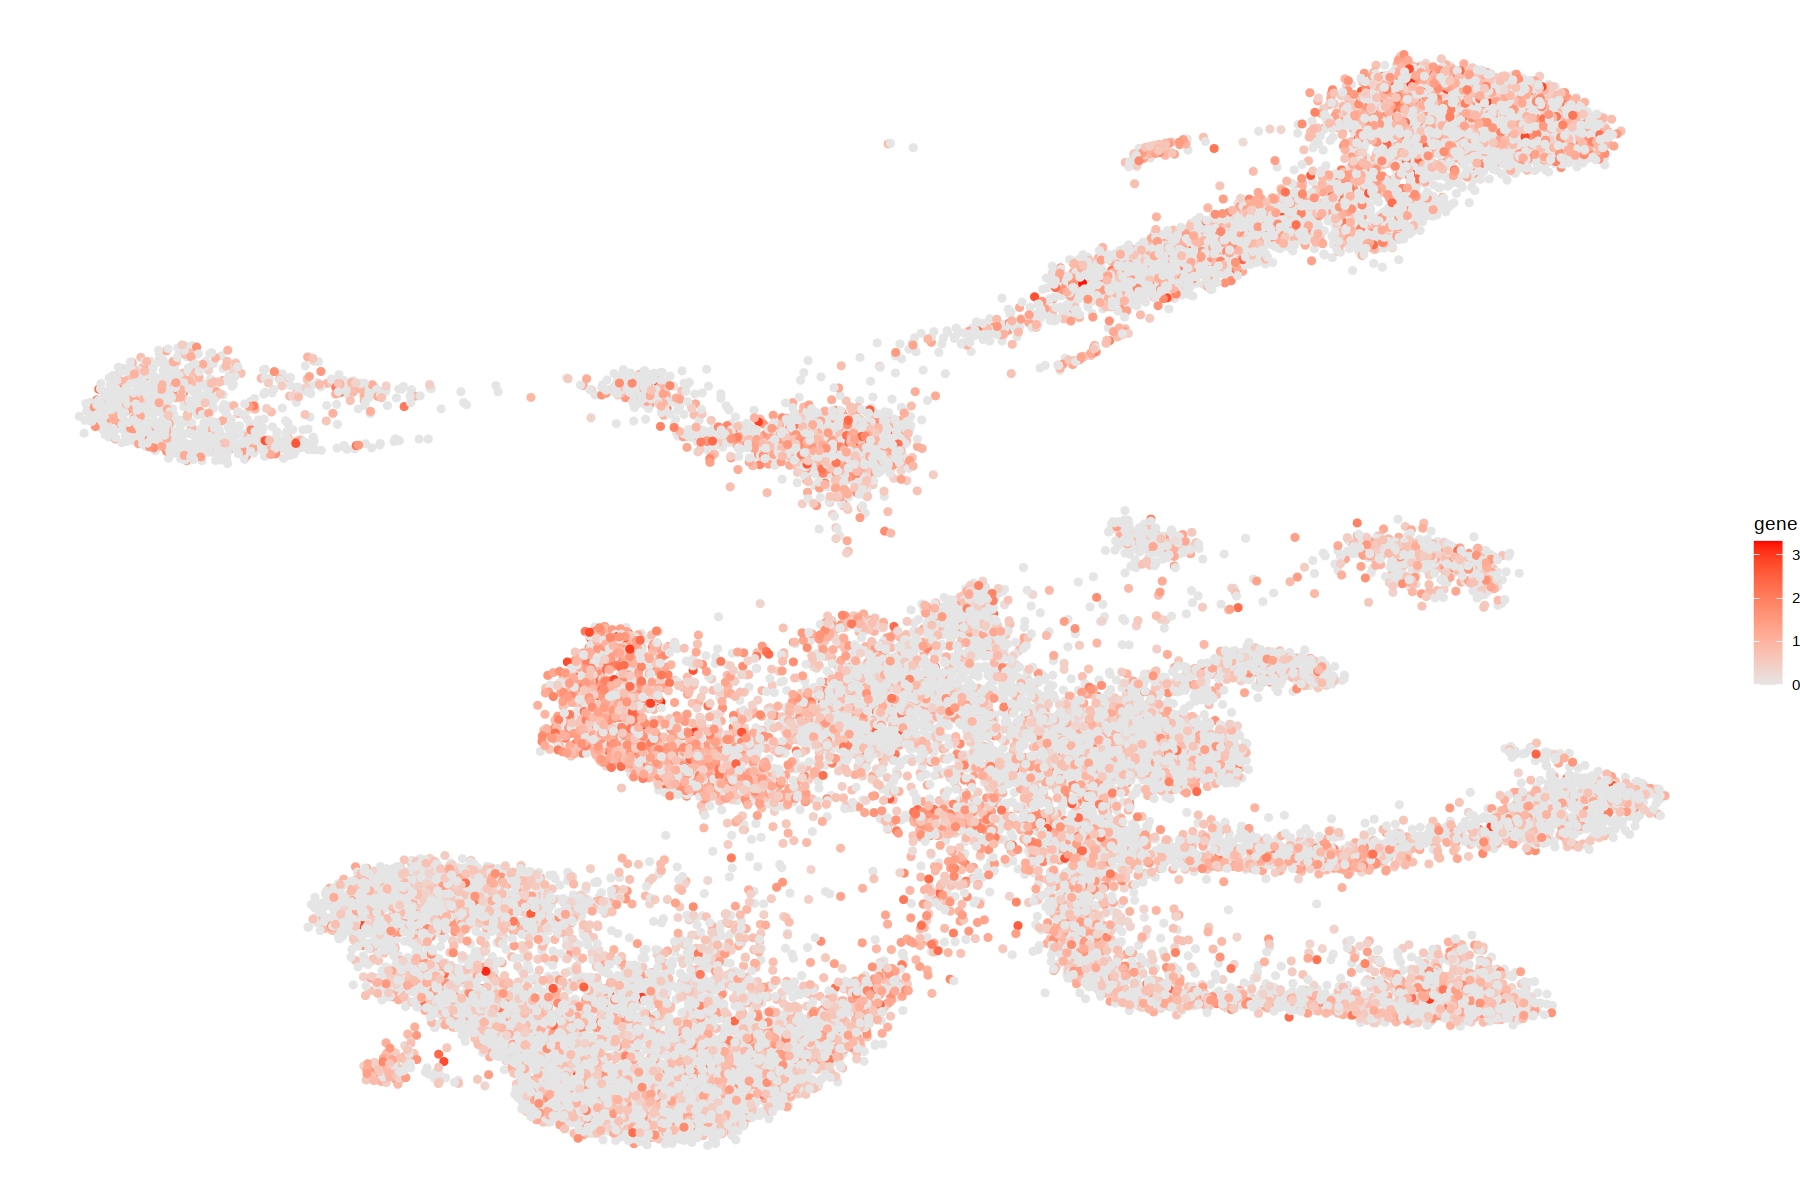

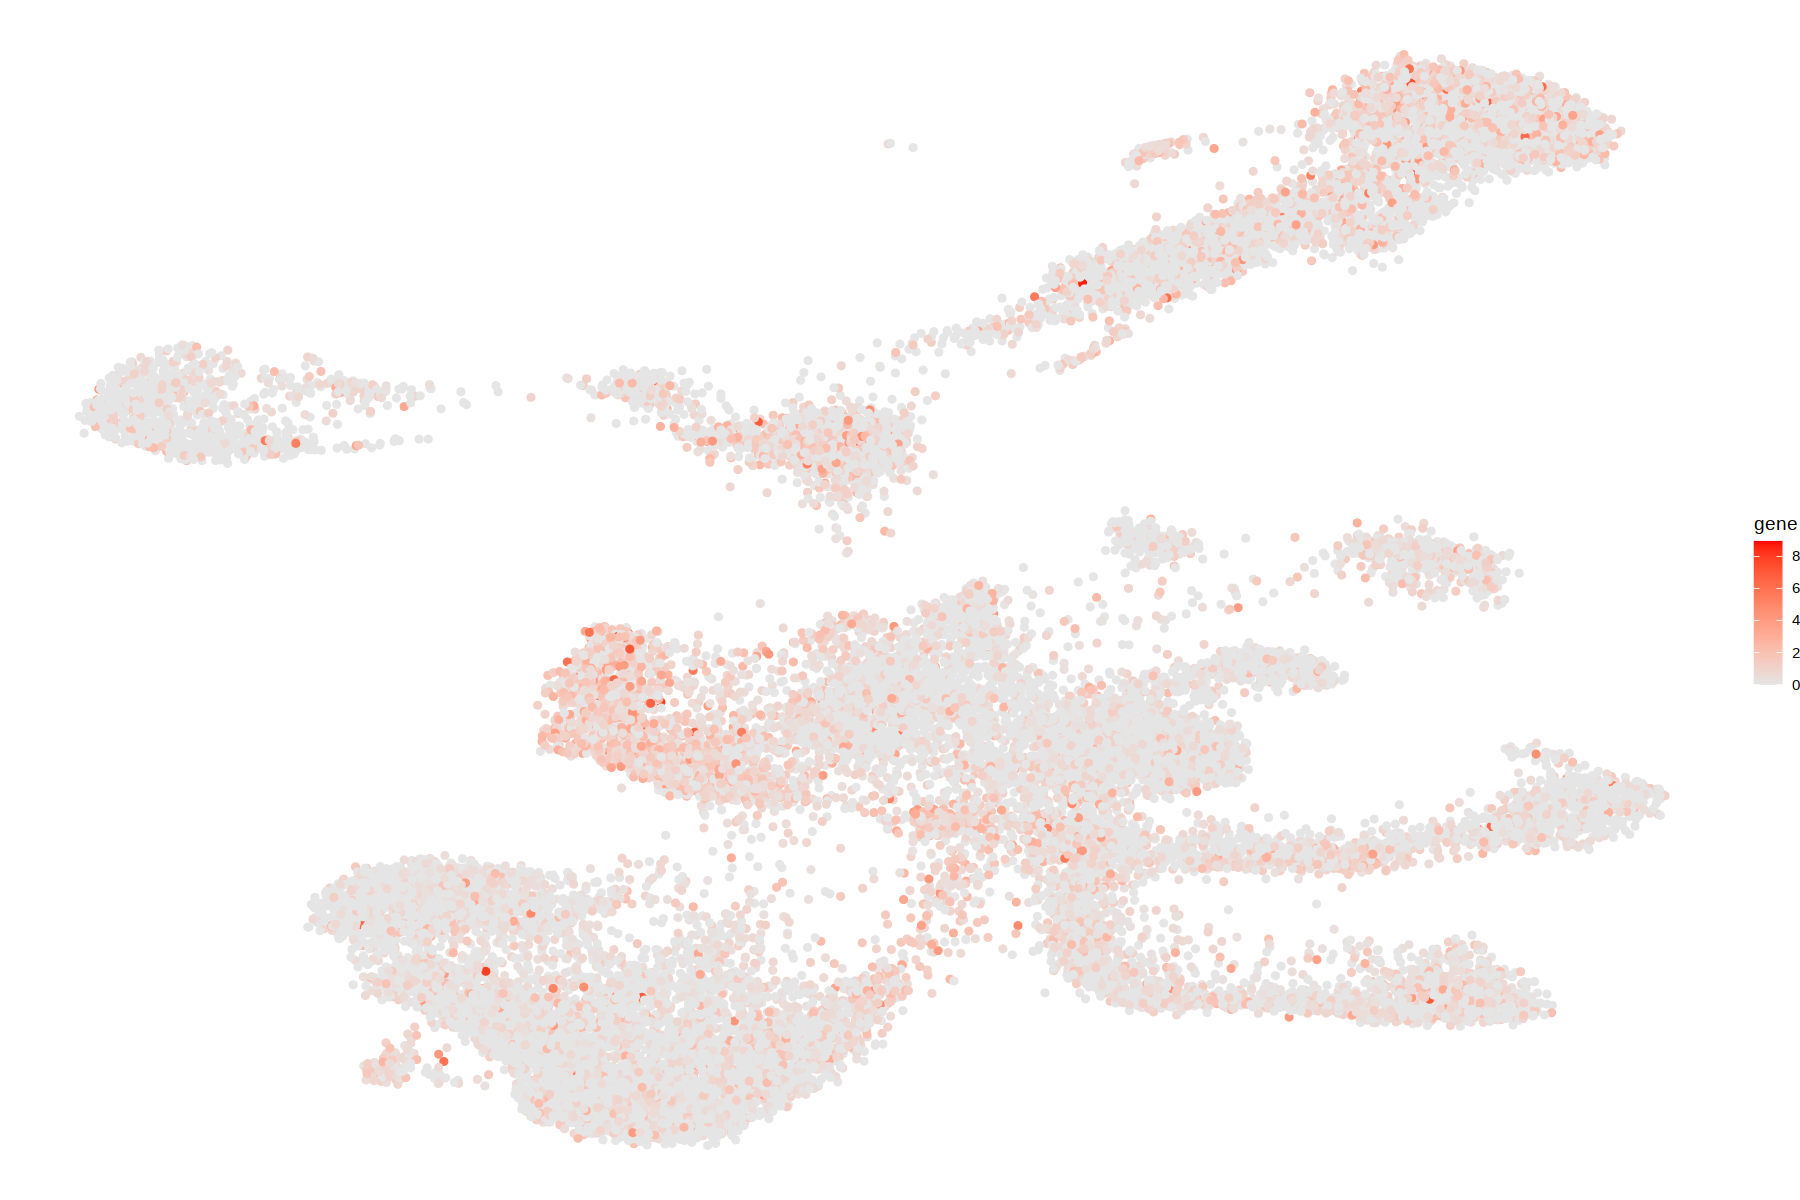

In [318]:
gene = 'HOXA10'
counts = data.table(cell = colnames(sce_filt), gene = as.vector(logcounts(sce_filt[gene])))
to.plot = merge(umap.dt2, counts, by='cell')
ggplot(to.plot, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point() + 
    scale_colour_gradient2(mid='gray90', high='red') + 
    theme_void()

counts = data.table(cell = colnames(sce_filt), gene = as.vector(counts(sce_filt[gene])))
to.plot = merge(umap.dt2, counts, by='cell')
ggplot(to.plot, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point() + 
    scale_colour_gradient2(mid='gray90', high='red') + 
    theme_void()

In [319]:
test = ArchR:::.normalizeCols(counts(sce_filt))

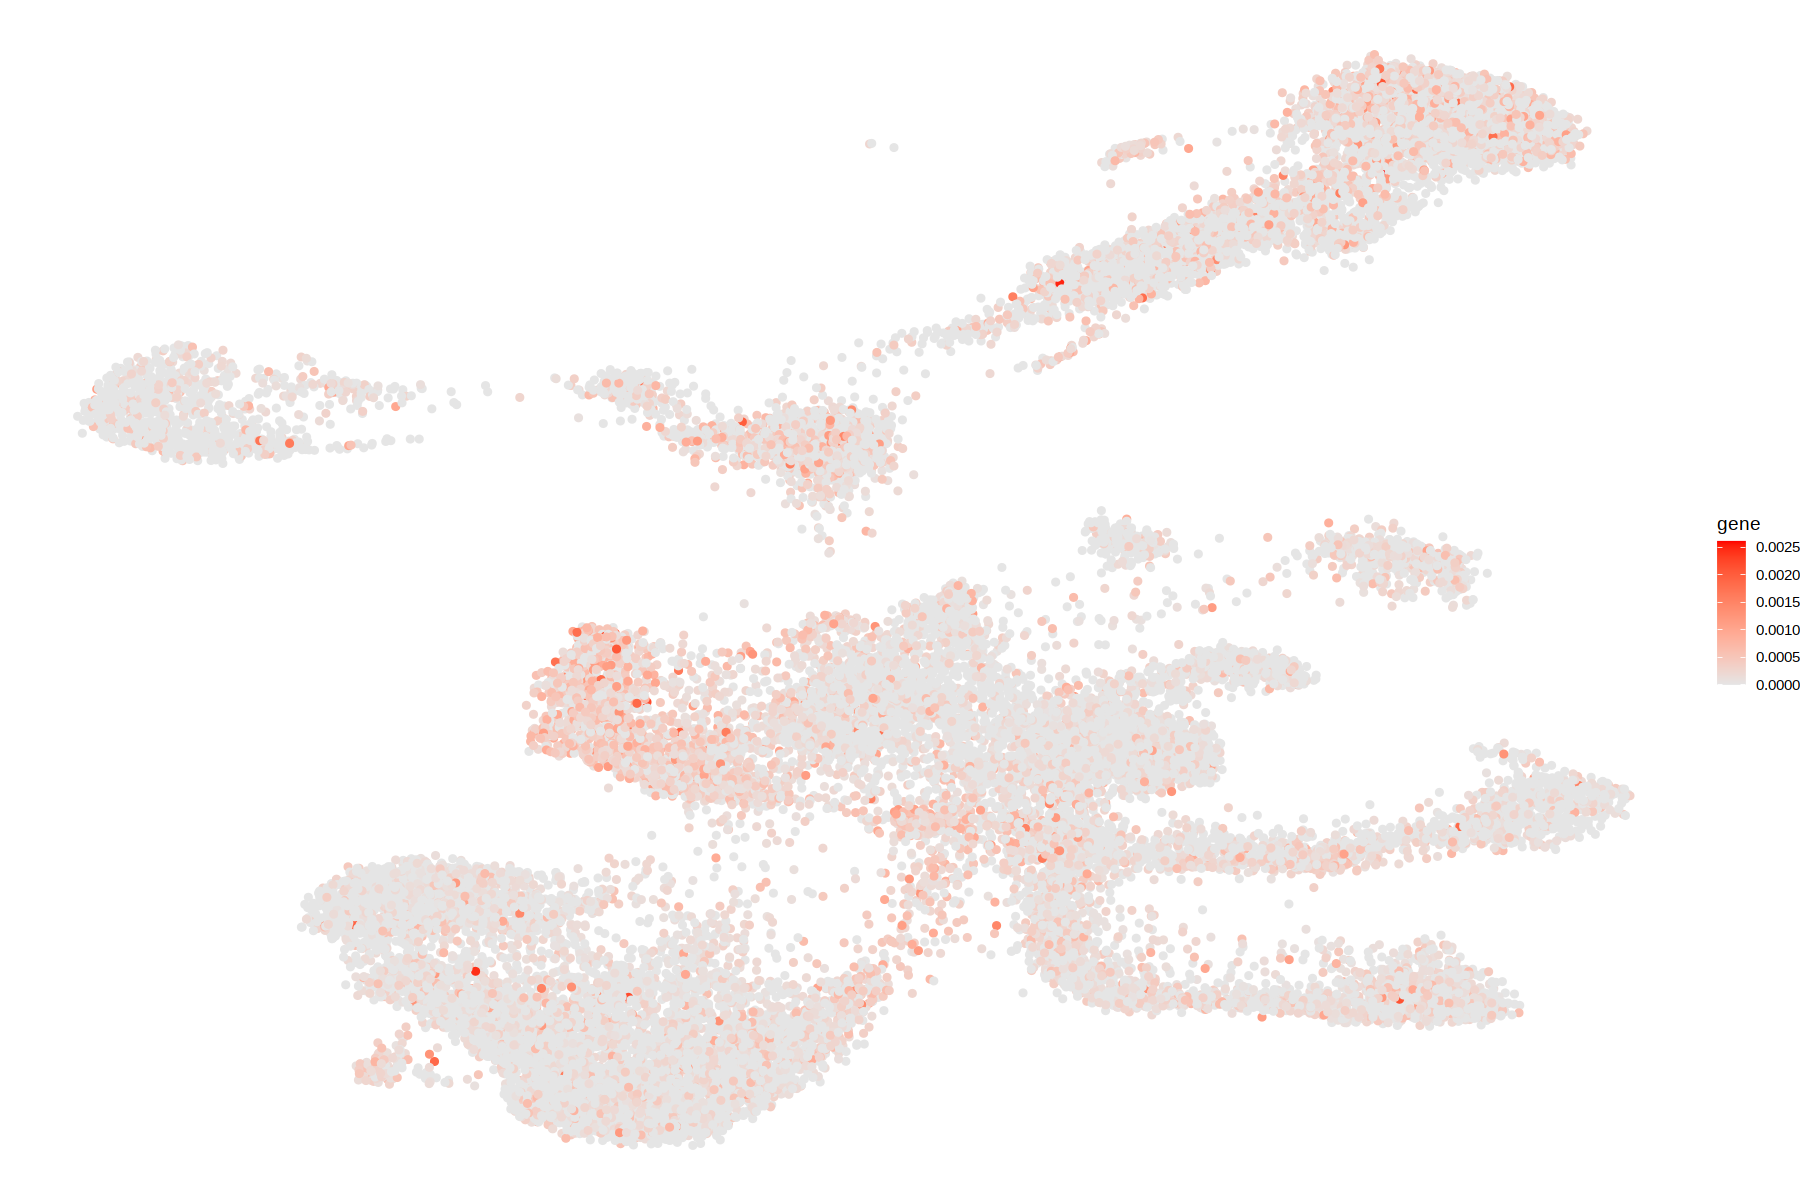

In [320]:
counts = data.table(cell = colnames(sce_filt), gene = log2(test[gene,]+1))
to.plot = merge(umap.dt2, counts, by='cell')
ggplot(to.plot, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point() + 
    scale_colour_gradient2(mid='gray90', high='red') + 
    theme_void()

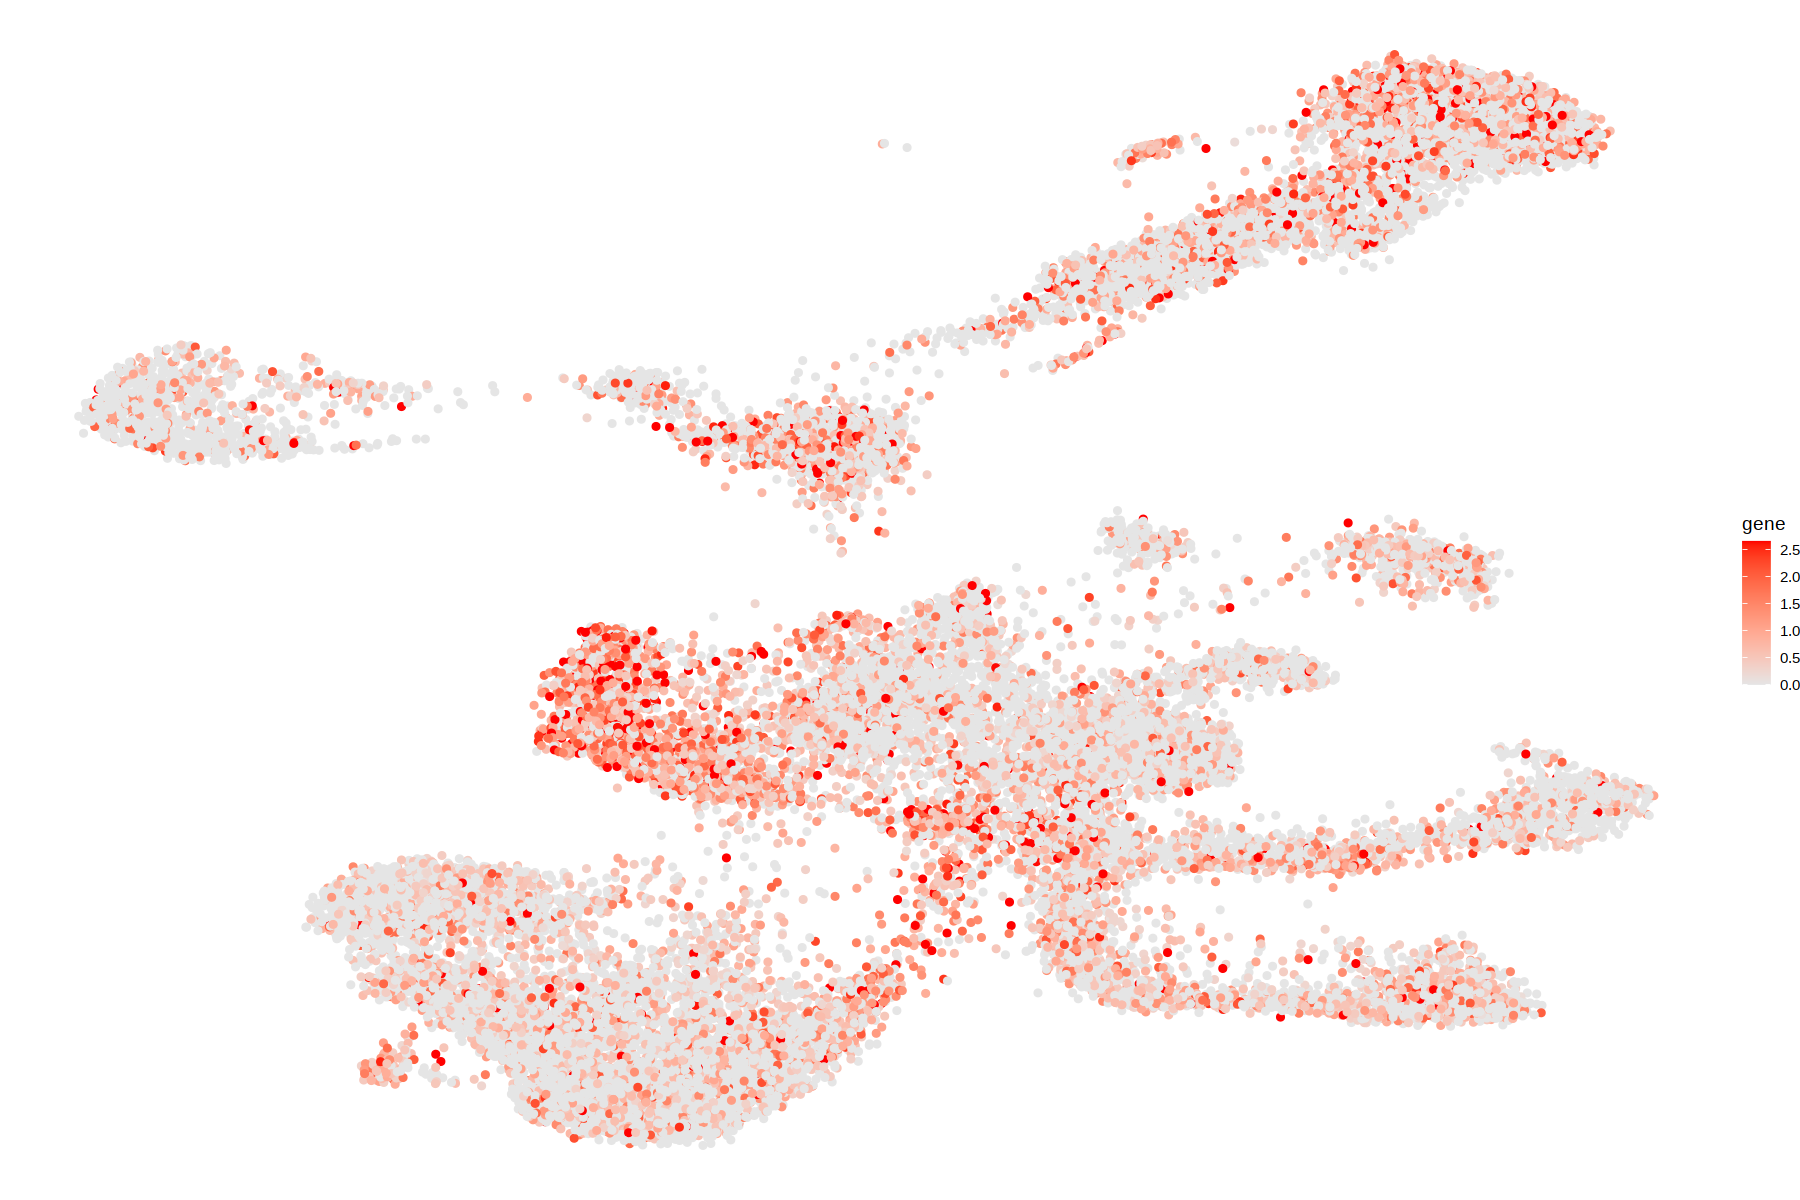

In [321]:
counts = data.table(cell = colnames(sce_filt), gene = ArchR:::.quantileCut(as.vector(counts(sce_filt[gene]))))
to.plot = merge(umap.dt2, counts, by='cell')
ggplot(to.plot, aes(UMAP1, UMAP2, col=gene)) + 
    geom_point() + 
    scale_colour_gradient2(mid='gray90', high='red') + 
    theme_void()


2022-11-22 18:17:12 : SuppressedMessaged due to getArchRVerbose() is FALSE!

2022-11-22 18:17:16 : SuppressedMessaged due to getArchRVerbose() is FALSE!



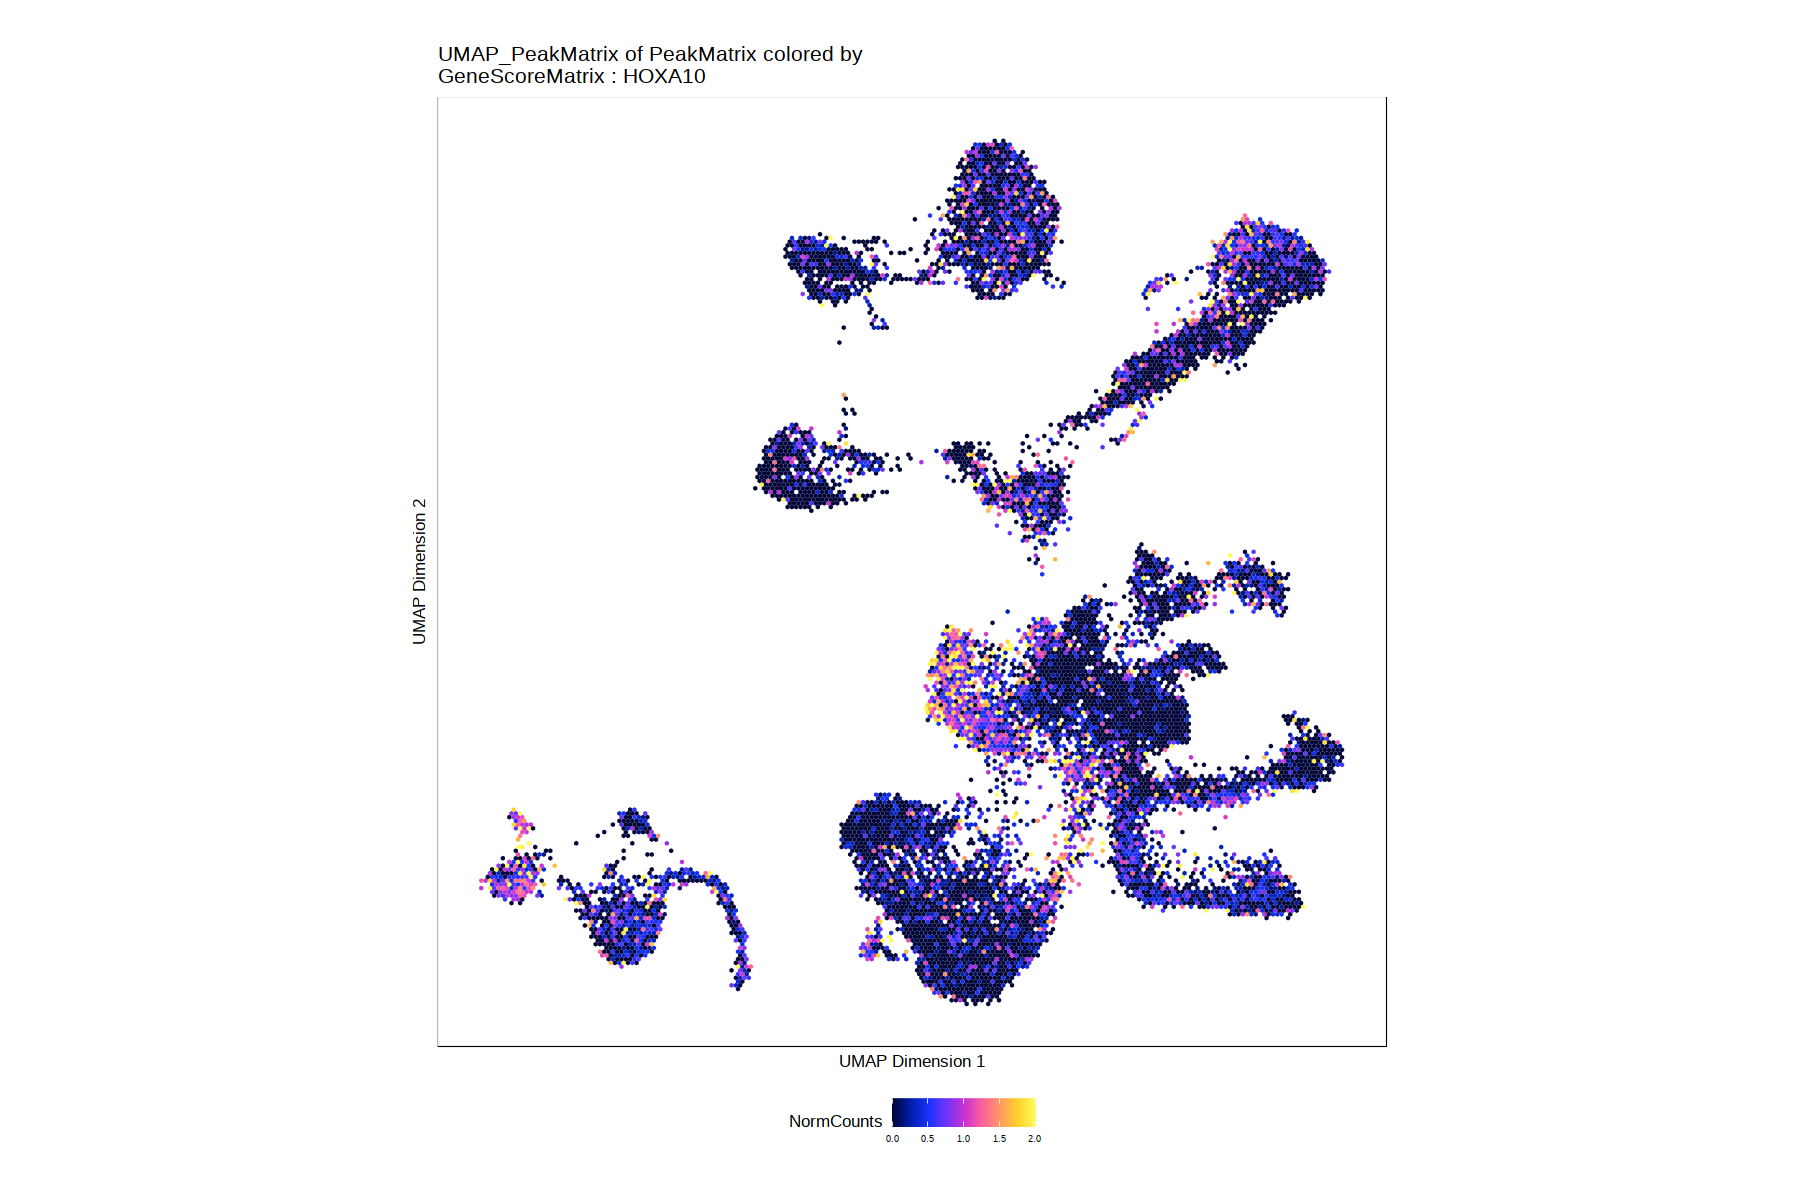

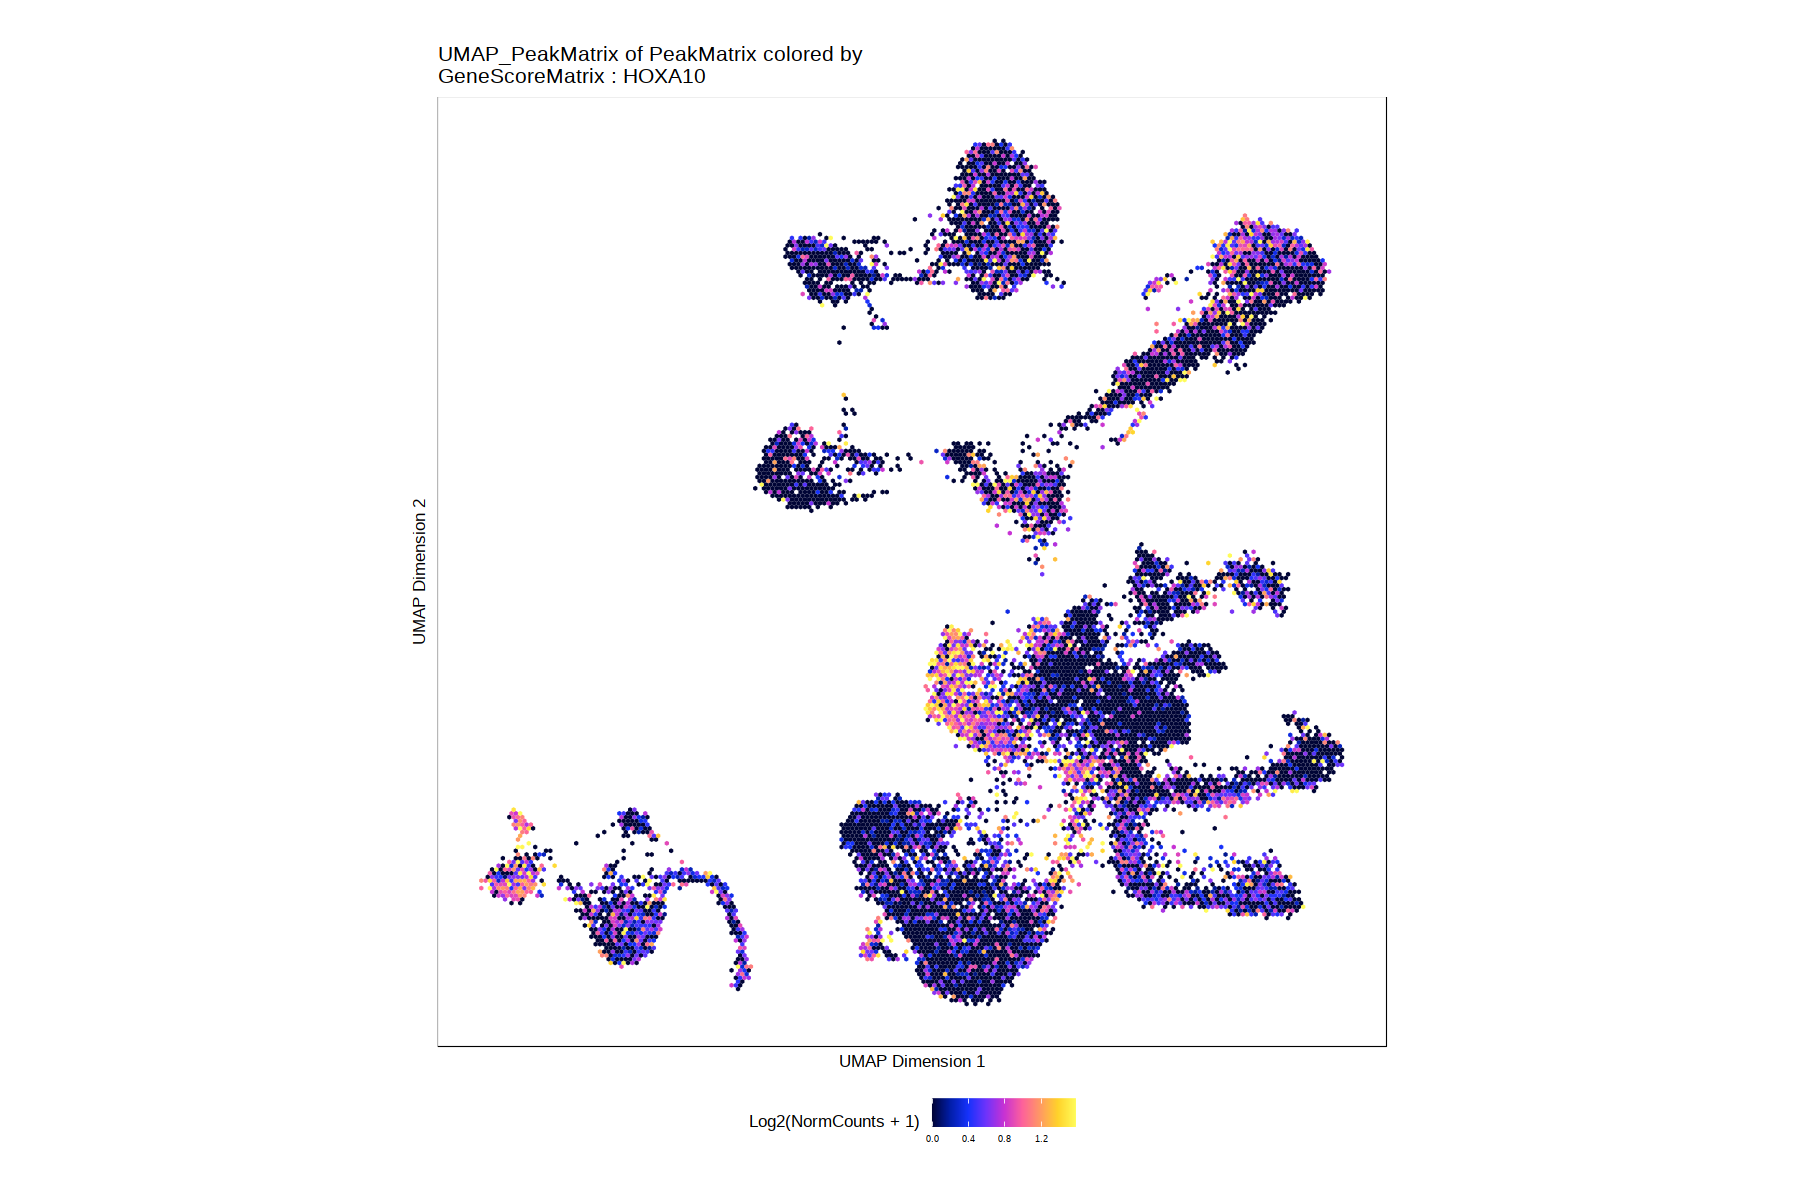

In [322]:
plotEmbedding(ArchRProj = ArchRProject,
              embedding = "UMAP_PeakMatrix",
              colorBy = "GeneScoreMatrix",
              name = gene,
             imputeWeights =NULL,
             log2Norm =FALSE)

plotEmbedding(ArchRProj = ArchRProject,
              embedding = "UMAP_PeakMatrix",
              colorBy = "GeneScoreMatrix",
              name = gene,
             imputeWeights =NULL,
             log2Norm =TRUE)